## Changes made to improve accuracy

The original run scored **59.7% accuracy with 0% recall/precision on the "Fake" class**
— the model had simply collapsed to always predicting "Real". The fixes below target
the root causes:

1. **Critical bug fix (Dataset class):** images were loaded using the row's *positional*
   index (`f"{idx}.jpg"`) instead of the Fakeddit submission id (`row["id"]`). Almost no
   files matched, so nearly every sample silently fell back to an all-zero image tensor —
   the image branch was contributing no real signal at all. Fixed to use `row["id"]`.
2. **Class-weighted loss** so the model can't get a low loss just by predicting the
   majority class on this imbalanced (~60/40) dataset.
3. **A real validation split** + best-checkpoint saving + early stopping, so training
   is actually monitored instead of trusting whatever the last epoch happens to produce.
4. **Differential learning rates** — a much higher LR for the randomly-initialized
   classifier head than for the pretrained encoders, plus a linear warmup/decay
   schedule and gradient clipping.
5. **Partial layer freezing** of DistilBERT/ResNet50's earlier layers to reduce
   overfitting given the small fine-tuning set.
6. **Light image augmentation** on the training split only (flip/crop/color jitter),
   with a separate clean deterministic transform for val/test.
7. **More training data** (configurable `NUM_SAMPLES`, raised from 5,000) and the
   training loop is now actually enabled (it was commented out before).


In [1]:
import os
import torch
import pandas as pd
import torch.nn as nn
import requests

from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from transformers import DistilBertTokenizer, DistilBertModel
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split

In [2]:
# print('Reinstalling torch and torchvision to resolve sympy compatibility issues. Please restart the runtime after this cell finishes.')
# !pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [3]:
# !unzip "fakeddit_images.zip"
# !unzip "xmap_model.zip"

In [4]:
df = pd.read_csv("test_public.csv")

print(df.shape)
print(df.head())

(59319, 16)
                author                                        clean_title  \
0         trustbytrust                                          stargazer   
1                  NaN                                               yeah   
2             chaseoes  pd phoenix car thief gets instructions from yo...   
3            SFepicure  as trump accuses iran he has one problem his o...   
4  fragments_from_Work                                believers hezbollah   

    created_utc       domain  hasImage       id  \
0  1.425139e+09          NaN      True  cozywbv   
1  1.438173e+09          NaN      True  ctk61yw   
2  1.560492e+09    abc15.com      True   c0gl7r   
3  1.560606e+09  nytimes.com      True   c0xdqy   
4  1.515139e+09  i.imgur.com      True   7o9rmx   

                                           image_url linked_submission_id  \
0                     http://i.imgur.com/BruWKDi.jpg               2xct9d   
1                     http://i.imgur.com/JRZT727.jpg            

### Download images from `image_url`

Only needed if `fakeddit_images/` doesn't already contain a matching `{id}.jpg` for
every row you plan to train on. Downloads are keyed by `id` (matching the Dataset
class fix above), skip files that already exist, retry on transient failures, and
run concurrently for speed. Rows with `hasImage == False` or a missing `image_url`
are skipped.

In [5]:
import os
import requests
from io import BytesIO
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

# ==========================
# Configuration
# ==========================

IMAGE_DIR = "fakeddit_images"
os.makedirs(IMAGE_DIR, exist_ok=True)

NUM_SAMPLES = 15000          # Number of samples to use

MAX_WORKERS = 32
TIMEOUT = 10
MAX_RETRIES = 2

HEADERS = {
    "User-Agent": "Mozilla/5.0 (X-MAP dataset builder)"
}

# ==========================
# Select rows
# ==========================

# BUG FIX: this used to take df.iloc[:DOWNLOAD_ROWS], i.e. the first
# NUM_SAMPLES rows of the raw CSV. The paper reports (and the training
# split later in the notebook performs) a *stratified* sample of
# NUM_SAMPLES rows on the 2_way_label column, not a positional slice.
# Downloading images for the positional slice while training on the
# stratified sample means images would be fetched for a different set
# of posts than the ones actually used for training/eval, so most
# training posts would fall back to a zero-image tensor.
#
# Fix: build subset_df here, via the same stratified sampling used in
# the training-split cell below, and download images for exactly this
# set. The training-split cell reuses this same subset_df (identical
# random_state=42) instead of recomputing it, so the downloaded images
# and the training/val/test split are guaranteed to reference the same
# 15,000 posts.
from sklearn.model_selection import train_test_split

subset_df, _ = train_test_split(
    df,
    train_size=NUM_SAMPLES,
    random_state=42,
    stratify=df["2_way_label"]
)
subset_df = subset_df.reset_index(drop=True)

download_df = subset_df.copy()

candidates = download_df[
    (download_df["hasImage"] == True) &
    (download_df["image_url"].notna())
]

print(f"Total rows selected      : {len(download_df)}")
print(f"Rows having image URL    : {len(candidates)}")

# ==========================
# Download function
# ==========================

def download_one(row):

    image_id = row["id"]
    url = row["image_url"]

    dest_path = os.path.join(
        IMAGE_DIR,
        f"{image_id}.jpg"
    )

    # Skip already downloaded images
    if os.path.exists(dest_path):
        return image_id, "skipped"

    for attempt in range(MAX_RETRIES + 1):

        try:
            response = requests.get(
                url,
                headers=HEADERS,
                timeout=TIMEOUT
            )

            response.raise_for_status()

            image = Image.open(
                BytesIO(response.content)
            ).convert("RGB")

            image.save(dest_path, "JPEG")

            return image_id, "downloaded"

        except Exception as e:

            if attempt == MAX_RETRIES:
                return image_id, f"failed: {e}"

# ==========================
# Parallel Download
# ==========================

results = {
    "downloaded": 0,
    "skipped": 0,
    "failed": 0
}

failures = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:

    futures = [
        executor.submit(download_one, row)
        for _, row in candidates.iterrows()
    ]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Downloading Images"
    ):

        image_id, status = future.result()

        if status == "downloaded":
            results["downloaded"] += 1

        elif status == "skipped":
            results["skipped"] += 1

        else:
            results["failed"] += 1
            failures.append((image_id, status))

# ==========================
# Summary
# ==========================

print("\nDownload Summary")
print("-" * 40)
print("Downloaded :", results["downloaded"])
print("Skipped    :", results["skipped"])
print("Failed     :", results["failed"])

print("\nTotal images available:",
      len(os.listdir(IMAGE_DIR)))

if failures:
    print("\nFirst 10 failures:")
    for image_id, status in failures[:10]:
        print(image_id, "-", status)

Total rows selected      : 15000
Rows having image URL    : 14959


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Download Summary
----------------------------------------
Downloaded : 14185
Skipped    : 0
Failed     : 774

Total images available: 14185

First 10 failures:
d7b6iq - failed: 404 Client Error: Not Found for url: https://preview.redd.it/njy6taj9jyn31.jpg?width=320&crop=smart&auto=webp&s=5e13eb4a5ec601767e8f4fc14c454fde3352188a
ddln4g - failed: 404 Client Error: Not Found for url: https://preview.redd.it/sy5icgqecpq31.jpg?width=320&crop=smart&auto=webp&s=0410b7bbbd7917dfad826fbb181413328e3c3660
2i7hqa - failed: 404 Client Error: Not Found for url: https://external-preview.redd.it/ESPM-tTuK3werLgfWG_wBsw_trUSDNU4bI5s2jVRAgQ.png?width=108&crop=smart&auto=webp&s=6bdf4d9c8ec6b3100f803c1cf0848f49a5aee344
axig22 - failed: 404 Client Error: Not Found for url: https://preview.redd.it/5q8vyqge69k21.jpg?width=320&crop=smart&auto=webp&s=0c6fd624e009a7f308641a288450d8005b4ac857
8g2b4r - failed: 404 Client Error: Not Found for url: https://preview.redd.it/2s1ea63bo3v01.jpg?width=320&crop=smart&aut

In [6]:
# Two separate pipelines:
# - train_transform: light augmentation so the image encoder sees more
#   varied views of each picture and doesn't just memorize the small
#   training set (previously identical to eval, i.e. zero regularization
#   for the vision branch).
# - eval_transform: deterministic, no augmentation, used for val/test so
#   metrics are stable and reproducible.
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Kept as an alias for backward compatibility with the LIME/GradCAM
# explainability cells later in the notebook, which expect a single
# deterministic transform.
transform = eval_transform

In [7]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
# NOTE: the previous version trained on only the first 5,000 rows and
# had no validation set, so the only way to see how training went was
# the final test-set numbers. Both are fixed here.
#
# Increase/decrease NUM_SAMPLES depending on how much time/compute you
# have (this CSV has ~59k rows) -- more labeled data gives the model
# more signal to learn the Fake vs Real boundary.
NUM_SAMPLES = 15000

# subset_df was already created in the image-download cell above via a
# stratified sample of NUM_SAMPLES rows on "2_way_label" (random_state=42),
# and images were downloaded for exactly that set. Reuse it here rather
# than recomputing/re-slicing, so the posts trained/evaluated on are
# identical to the posts images were fetched for.
assert "subset_df" in dir(), "Run the image-download cell first to build subset_df."
assert len(subset_df) == NUM_SAMPLES

# Split off a held-out test set first, then split the remainder into
# train/val. The val set lets us monitor generalization *during*
# training (checkpointing the best epoch, early stopping) instead of
# only discovering a collapsed model after the fact.
train_df, temp_df = train_test_split(
    subset_df,
    test_size=0.3,
    random_state=42,
    stratify=subset_df["2_way_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=(2 / 3),   # -> 10% val / 20% test of the full subset
    random_state=42,
    stratify=temp_df["2_way_label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print(train_df["2_way_label"].value_counts(normalize=True))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 10500
2_way_label
0    0.603714
1    0.396286
Name: proportion, dtype: float64
Val  : 1500
Test : 3000


### Cross-split overlap / data-leakage audit

Addresses the reviewer concern that a random stratified split does not by itself rule out duplicate/near-duplicate posts, repeated image URLs, or heavy source/domain overlap between train, validation, and test. This audits the split already used above; it does **not** re-split or retrain.

In [9]:
# ============================================================
# Cross-Split Overlap / Data-Leakage Audit
# ============================================================
# Reviewer concern: a random stratified split does not guarantee the
# train/val/test partitions are free of duplicate or near-duplicate
# posts, repeated source URLs, or heavy source/domain overlap. Any of
# these could let the model "leak" information from train into test
# (e.g. memorizing a headline it saw verbatim, or learning a
# source-specific artifact rather than a generalizable cue).
#
# This cell audits the EXISTING 70/10/20 split (no retraining, no
# re-splitting) and reports:
#   1. Exact duplicate `clean_title` text across splits
#   2. Duplicate `image_url` across splits (same image reused)
#   3. Domain/source overlap across splits
#   4. Near-duplicate headlines across splits (TF-IDF cosine similarity)
#
# Same-domain-in-two-splits is NOT automatically leakage (e.g. two
# different BBC articles) -- it's flagged separately from exact/near
# duplicate text, which IS a strong leakage signal.

import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option("display.max_colwidth", 100)


def normalize_text(text):
    """Lowercase, strip punctuation/extra whitespace for near-duplicate matching."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


splits = {
    "train": train_df.copy(),
    "val": val_df.copy(),
    "test": test_df.copy(),
}
for name, d in splits.items():
    d["norm_title"] = d["clean_title"].apply(normalize_text)

pairs = [("train", "val"), ("train", "test"), ("val", "test")]

# ------------------------------------------------------------
# 1 & 2. Exact duplicate text and duplicate image_url
# ------------------------------------------------------------
print("=" * 70)
print("1. EXACT DUPLICATE TEXT & IMAGE URL OVERLAP")
print("=" * 70)

exact_dup_rows = []
for a, b in pairs:
    da, db = splits[a], splits[b]

    titles_a = set(da["clean_title"].dropna())
    titles_b = set(db["clean_title"].dropna())
    exact_title_overlap = titles_a & titles_b

    norm_a = set(da["norm_title"].dropna())
    norm_b = set(db["norm_title"].dropna())
    norm_title_overlap = norm_a & norm_b

    urls_a = set(da["image_url"].dropna())
    urls_b = set(db["image_url"].dropna())
    url_overlap = urls_a & urls_b

    exact_dup_rows.append({
        "split_pair": f"{a}-{b}",
        "exact_clean_title_dupes": len(exact_title_overlap),
        "normalized_title_dupes": len(norm_title_overlap),
        "shared_image_urls": len(url_overlap),
    })

exact_dup_df = pd.DataFrame(exact_dup_rows)
print(exact_dup_df.to_string(index=False))

# ------------------------------------------------------------
# 3. Domain / source overlap
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("2. DOMAIN / SOURCE OVERLAP")
print("=" * 70)

domain_rows = []
for a, b in pairs:
    da, db = splits[a], splits[b]

    domains_a = set(da["domain"].dropna())
    domains_b = set(db["domain"].dropna())
    shared_domains = domains_a & domains_b

    # How many rows in split b come from a domain also seen in split a
    rows_from_shared_domain = db["domain"].isin(shared_domains).sum()

    domain_rows.append({
        "split_pair": f"{a}-{b}",
        "domains_in_first": len(domains_a),
        "domains_in_second": len(domains_b),
        "shared_domains": len(shared_domains),
        f"rows_in_second_from_shared_domain": int(rows_from_shared_domain),
        "pct_of_second": round(100 * rows_from_shared_domain / len(db), 2),
    })

domain_df = pd.DataFrame(domain_rows)
print(domain_df.to_string(index=False))

top_shared = (
    set(splits["train"]["domain"].dropna()) & set(splits["test"]["domain"].dropna())
)
print(f"\nExample shared train/test domains (up to 15): {sorted(list(top_shared))[:15]}")

# ------------------------------------------------------------
# 4. Near-duplicate headlines (TF-IDF cosine similarity)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("3. NEAR-DUPLICATE HEADLINES (train vs. test, TF-IDF cosine >= 0.9)")
print("=" * 70)

SIMILARITY_THRESHOLD = 0.9
MAX_EXAMPLES_TO_SHOW = 10

train_titles = splits["train"]["norm_title"].tolist()
test_titles = splits["test"]["norm_title"].tolist()

vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1)
all_titles = train_titles + test_titles
tfidf_matrix = vectorizer.fit_transform(all_titles)

train_matrix = tfidf_matrix[: len(train_titles)]
test_matrix = tfidf_matrix[len(train_titles):]

# Chunk over the test set to keep memory bounded
near_dup_pairs = []
CHUNK = 500
for start in range(0, test_matrix.shape[0], CHUNK):
    end = min(start + CHUNK, test_matrix.shape[0])
    sim_chunk = (test_matrix[start:end] @ train_matrix.T).toarray()
    rows, cols = np.where(sim_chunk >= SIMILARITY_THRESHOLD)
    for r, c in zip(rows, cols):
        near_dup_pairs.append((start + r, c, sim_chunk[r, c]))

print(f"Near-duplicate pairs found (similarity >= {SIMILARITY_THRESHOLD}): {len(near_dup_pairs)}")
print(f"Unique test posts involved: {len(set(p[0] for p in near_dup_pairs))} "
      f"out of {len(test_titles)} test posts "
      f"({100 * len(set(p[0] for p in near_dup_pairs)) / len(test_titles):.2f}%)")

if near_dup_pairs:
    print(f"\nExample near-duplicate pairs (up to {MAX_EXAMPLES_TO_SHOW}):")
    for test_idx, train_idx, sim in sorted(near_dup_pairs, key=lambda x: -x[2])[:MAX_EXAMPLES_TO_SHOW]:
        print(f"\n  similarity={sim:.3f}")
        print(f"  [train] {splits['train'].iloc[train_idx]['clean_title']}")
        print(f"  [test ] {splits['test'].iloc[test_idx]['clean_title']}")

print("\n" + "=" * 70)
print("SUMMARY (fill these into the paper's overlap-audit subsection)")
print("=" * 70)
print(exact_dup_df.to_string(index=False))
print()
print(domain_df.to_string(index=False))
print()
print(f"Near-duplicate train/test pairs (cosine >= {SIMILARITY_THRESHOLD}): {len(near_dup_pairs)}")


1. EXACT DUPLICATE TEXT & IMAGE URL OVERLAP
split_pair  exact_clean_title_dupes  normalized_title_dupes  shared_image_urls
 train-val                       28                      28                  8
train-test                       54                      54                 17
  val-test                       17                      17                  4

2. DOMAIN / SOURCE OVERLAP
split_pair  domains_in_first  domains_in_second  shared_domains  rows_in_second_from_shared_domain  pct_of_second
 train-val               870                189             100                                945          63.00
train-test               870                330             171                               1974          65.80
  val-test               189                330              66                               1817          60.57

Example shared train/test domains (up to 15): ['29.media.tumblr.com', '31.media.tumblr.com', '9news.com.au', 'abc.net.au', 'abc13.com', 'abc15.com', 'abc7.

### Group-wise, duplicate-aware re-split (replaces the random split above)

The audit above found genuine duplicate/near-duplicate content across train and test (54 exact-duplicate headlines, 17 shared image URLs, and near-duplicates touching 5.23% of the test set) -- not just same-domain overlap. Per the reviewer's guidance, this crosses the threshold where the fix is a duplicate-aware, group-wise re-split and retraining, not just reporting the audit. Everything from the Dataset construction cell onward must be re-run on the resulting `train_df` / `val_df` / `test_df`.

In [10]:
# ============================================================
# Group-wise, duplicate-aware re-split
# ============================================================
# The overlap audit above found 54 exact-duplicate clean_title matches
# and 17 shared image_url values between the original train and test
# partitions, plus near-duplicate headlines (TF-IDF cosine >= 0.90)
# touching 5.23% of test posts. Some of that is driven by generic
# boilerplate captions (e.g. "other discussions"), but the audit also
# surfaced genuine, specific duplicate content -- e.g. the exact same
# headline ("fan who got lions super bowl tattoo still really
# optimistic about chances") appearing verbatim in both train and
# test -- plus posts whose image was literally reused across
# partitions. That is content leakage, not just same-domain overlap,
# so the split is redone here so that no duplicate/near-duplicate
# cluster is ever split across train/val/test.
#
# This cell REPLACES train_df / val_df / test_df. Everything from the
# Dataset construction cell onward must be re-run (and the model
# retrained) on this new split.

import numpy as np
from collections import defaultdict
from sklearn.model_selection import StratifiedGroupKFold

# ---- 1. Build duplicate clusters over the full 15,000-post subset ----

subset_df = subset_df.reset_index(drop=True)
n = len(subset_df)
subset_df["norm_title"] = subset_df["clean_title"].apply(normalize_text)

parent = list(range(n))


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[ry] = rx


# a) exact/normalized title match
title_groups = defaultdict(list)
for i, t in enumerate(subset_df["norm_title"]):
    title_groups[t].append(i)
for idxs in title_groups.values():
    for j in idxs[1:]:
        union(idxs[0], j)

# b) shared image_url
url_groups = defaultdict(list)
for i, u in enumerate(subset_df["image_url"]):
    if pd.notna(u):
        url_groups[u].append(i)
for idxs in url_groups.values():
    for j in idxs[1:]:
        union(idxs[0], j)

# c) near-duplicate title (TF-IDF cosine >= 0.90), chunked to bound memory
vectorizer_full = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1)
tfidf_full = vectorizer_full.fit_transform(subset_df["norm_title"])

CHUNK = 1000
SIM_THRESHOLD = 0.9
for start in range(0, n, CHUNK):
    end = min(start + CHUNK, n)
    sim_chunk = (tfidf_full[start:end] @ tfidf_full[start:].T).toarray()
    for local_i in range(end - start):
        i = start + local_i
        row = sim_chunk[local_i]
        matches = np.where(row >= SIM_THRESHOLD)[0] + start
        for j in matches:
            if j > i:
                union(i, j)

subset_df["dup_cluster"] = [find(i) for i in range(n)]

n_clusters = subset_df["dup_cluster"].nunique()
print(f"{n} posts collapse into {n_clusters} duplicate-aware clusters "
      f"({n - n_clusters} posts merged into an existing cluster).")
largest = subset_df.groupby("dup_cluster").size().sort_values(ascending=False)
print("Largest clusters (cluster_id -> size):")
print(largest.head(10))

# ---- 2. Group-wise stratified split: clusters never cross a partition ----

labels = subset_df["2_way_label"].values
groups = subset_df["dup_cluster"].values

# Carve off ~20% as test, keeping clusters intact and labels balanced.
sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
trainval_idx, test_idx = next(sgkf_test.split(subset_df, labels, groups))

trainval_df = subset_df.iloc[trainval_idx].reset_index(drop=True)
test_df = subset_df.iloc[test_idx].reset_index(drop=True)

# Carve val (~1/8 of the remaining ~80% -> ~10% of the full subset) out
# of the training pool, again keeping clusters intact.
sgkf_val = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=42)
tv_labels = trainval_df["2_way_label"].values
tv_groups = trainval_df["dup_cluster"].values
train_idx, val_idx = next(sgkf_val.split(trainval_df, tv_labels, tv_groups))

train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

print("\nNew duplicate-aware split sizes:")
print("Train:", len(train_df), train_df["2_way_label"].value_counts(normalize=True).to_dict())
print("Val  :", len(val_df), val_df["2_way_label"].value_counts(normalize=True).to_dict())
print("Test :", len(test_df), test_df["2_way_label"].value_counts(normalize=True).to_dict())

# ---- 3. Verify zero cluster leakage across the new partitions ----

train_clusters = set(train_df["dup_cluster"])
val_clusters = set(val_df["dup_cluster"])
test_clusters = set(test_df["dup_cluster"])

print("\nCluster overlap after re-split (must all be 0):")
print("train n val :", len(train_clusters & val_clusters))
print("train n test:", len(train_clusters & test_clusters))
print("val n test  :", len(val_clusters & test_clusters))


15000 posts collapse into 14085 duplicate-aware clusters (915 posts merged into an existing cluster).
Largest clusters (cluster_id -> size):
dup_cluster
94      185
40      167
39       81
48       62
175      32
1901     25
449      10
73       10
171      10
2193      8
dtype: int64

New duplicate-aware split sizes:
Train: 10624 {0: 0.6057040662650602, 1: 0.39429593373493976}
Val  : 1476 {0: 0.6077235772357723, 1: 0.39227642276422764}
Test : 2900 {0: 0.5944827586206897, 1: 0.40551724137931033}

Cluster overlap after re-split (must all be 0):
train n val : 0
train n test: 0
val n test  : 0


### Image availability audit (overall and by class)


In [11]:
def image_availability_stats(dataframe, image_dir):
    available = 0
    missing = 0
    for _, row in dataframe.iterrows():
        image_path = os.path.join(image_dir, f"{row['id']}.jpg")
        if os.path.exists(image_path):
            available += 1
        else:
            missing += 1
    total = len(dataframe)
    return {
        "total": total,
        "available": available,
        "missing": missing,
        "missing_pct": 100 * missing / total
    }

print("Train:     ", image_availability_stats(train_df, IMAGE_DIR))
print("Validation:", image_availability_stats(val_df, IMAGE_DIR))
print("Test:      ", image_availability_stats(test_df, IMAGE_DIR))

# Missingness broken down by Real (0) vs Fake (1) label -- this is what
# tells us whether missing images are evenly spread across classes or
# concentrated in one of them.
for name, split in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    split = split.copy()
    split["image_available"] = split["id"].apply(
        lambda x: os.path.exists(os.path.join(IMAGE_DIR, f"{x}.jpg"))
    )
    print("\n", name)
    print(
        split.groupby("2_way_label")["image_available"]
        .agg(["count", "sum"])
        .rename(columns={"count": "total", "sum": "available"})
        .assign(missing=lambda d: d["total"] - d["available"],
                missing_pct=lambda d: 100 * (d["total"] - d["available"]) / d["total"])
    )


Train:      {'total': 10624, 'available': 10042, 'missing': 582, 'missing_pct': 5.4781626506024095}
Validation: {'total': 1476, 'available': 1398, 'missing': 78, 'missing_pct': 5.284552845528455}
Test:       {'total': 2900, 'available': 2745, 'missing': 155, 'missing_pct': 5.344827586206897}

 Train
             total  available  missing  missing_pct
2_way_label                                        
0             6435       6166      269     4.180264
1             4189       3876      313     7.471950

 Validation
             total  available  missing  missing_pct
2_way_label                                        
0              897        862       35     3.901895
1              579        536       43     7.426598

 Test
             total  available  missing  missing_pct
2_way_label                                        
0             1724       1654       70     4.060325
1             1176       1091       85     7.227891


In [12]:
class FakedditDataset(Dataset):

    def __init__(self, dataframe, tokenizer, image_transform=None, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        # Text
        text = str(row["clean_title"])

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        # Image
        # BUG FIX: image files are named after the Fakeddit submission id
        # (row["id"], e.g. "cozywbv.jpg") -- NOT the positional row index.
        # The original code built the path from `idx`, so for nearly every
        # sample it pointed at a file that doesn't exist and silently fell
        # back to an all-zero image tensor. That means the image branch
        # was feeding the model an (almost) identical, uninformative
        # signal for the entire dataset -- a major reason the model
        # collapsed to predicting a single class.
        image_id = row["id"]
        image_path = os.path.join("fakeddit_images", f"{image_id}.jpg")

        # image_available flags whether the real image (not the zero-tensor
        # fallback) was used for this sample, so downstream code can report
        # how much of each split fell back to the placeholder and can
        # evaluate test performance separately for the two groups.
        try:
            if os.path.exists(image_path):
                image = Image.open(image_path).convert("RGB")

                if self.image_transform:
                    image = self.image_transform(image)

                image_available = 1

            else:
                image = torch.zeros((3, 224, 224))
                image_available = 0

        except Exception:
            image = torch.zeros((3, 224, 224))
            image_available = 0

        # Label
        label = torch.tensor(
            int(row["2_way_label"]),
            dtype=torch.long
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "image": image,
            "label": label,
            "image_available": image_available
        }


In [13]:
train_dataset = FakedditDataset(
    dataframe=train_df,
    tokenizer=tokenizer,
    image_transform=train_transform
)

val_dataset = FakedditDataset(
    dataframe=val_df,
    tokenizer=tokenizer,
    image_transform=eval_transform
)

test_dataset = FakedditDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    image_transform=eval_transform
)

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

10624
1476
2900


In [15]:
class XMAP(nn.Module):

    def __init__(self, freeze_text_layers=4, freeze_image_blocks=("layer1", "layer2")):
        super(XMAP, self).__init__()

        # Text Encoder
        self.text_encoder = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )

        # Freeze the embeddings + first N transformer layers of DistilBERT.
        # With only a few thousand fine-tuning examples, updating every
        # parameter overfits fast and can wreck the pretrained language
        # representations (catastrophic forgetting). Freezing the lower
        # layers keeps general language features intact and lets only the
        # top layers (more task-specific) adapt.
        for param in self.text_encoder.embeddings.parameters():
            param.requires_grad = False

        for layer in self.text_encoder.transformer.layer[:freeze_text_layers]:
            for param in layer.parameters():
                param.requires_grad = False

        # Image Encoder
        self.image_encoder = resnet50(
            weights=ResNet50_Weights.DEFAULT
        )

        # Freeze the early conv blocks (generic edge/texture features) and
        # only fine-tune the later blocks, which encode more task-specific
        # visual features -- same overfitting rationale as above.
        for name, child in self.image_encoder.named_children():
            if name in freeze_image_blocks:
                for param in child.parameters():
                    param.requires_grad = False

        # Remove the final classification layer
        self.image_encoder.fc = nn.Identity()

        # Multimodal Classifier
        # Added BatchNorm after each hidden layer for more stable training
        # now that the encoders and head are trained with different LRs,
        # and slightly higher dropout on the first layer since 768+2048
        # concatenated features is a wide, overfit-prone input for a few
        # thousand training examples.
        self.classifier = nn.Sequential(
            nn.Linear(768 + 2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask, images):

        # Text Features
        text_output = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_features = text_output.last_hidden_state[:, 0, :]

        # Image Features
        image_features = self.image_encoder(images)

        # Feature Fusion
        fusion = torch.cat(
            (text_features, image_features),
            dim=1
        )

        # Classification
        logits = self.classifier(fusion)

        return logits, fusion

In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = XMAP().to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


In [17]:
# The dataset is imbalanced (~60/40 in this subset). An unweighted loss
# lets the model reach a low average loss just by always predicting the
# majority class -- exactly the failure mode from before (0% recall on
# the Fake class). Weighting by inverse class frequency makes mistakes
# on the minority class cost more, pushing the model to actually learn
# to distinguish it.
class_counts = train_df["2_way_label"].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (len(class_counts) * c) for c in class_counts],
    dtype=torch.float
).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class weights: tensor([0.8255, 1.2681], device='cuda:0')


In [18]:
from transformers import get_linear_schedule_with_warmup

NUM_EPOCHS = 3

# Differential learning rates: the pretrained encoders only need small
# nudges, while the freshly-initialized classifier head needs to learn
# from scratch and benefits from a much higher learning rate. A single
# tiny LR (2e-5) for everything -- as before -- barely moves the
# randomly-initialized classifier weights in a handful of epochs, which
# is a big part of why the model never learned to use the Fake class.
optimizer = AdamW([
    {"params": [p for p in model.text_encoder.parameters() if p.requires_grad], "lr": 2e-5},
    {"params": [p for p in model.image_encoder.parameters() if p.requires_grad], "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-3},
], weight_decay=0.01)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [19]:
# # ============================
# # Training Loop
# # ============================
# from sklearn.metrics import accuracy_score, f1_score

# best_val_f1 = 0.0
# patience = 2
# patience_counter = 0

# for epoch in range(NUM_EPOCHS):

#     # ---- Train ----
#     model.train()
#     total_loss = 0

#     for batch in train_loader:

#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         images = batch["image"].to(device)
#         labels = batch["label"].to(device)

#         optimizer.zero_grad()

#         outputs, fusion = model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             images=images
#         )

#         loss = criterion(outputs, labels)

#         loss.backward()

#         # Gradient clipping stabilizes training when fine-tuning large
#         # pretrained encoders jointly with a randomly-initialized head.
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()
#         scheduler.step()

#         total_loss += loss.item()

#     avg_loss = total_loss / len(train_loader)

#     # ---- Validate ----
#     model.eval()
#     val_preds, val_labels = [], []

#     with torch.no_grad():
#         for batch in val_loader:

#             input_ids = batch["input_ids"].to(device)
#             attention_mask = batch["attention_mask"].to(device)
#             images = batch["image"].to(device)
#             labels = batch["label"].to(device)

#             outputs, _ = model(
#                 input_ids=input_ids,
#                 attention_mask=attention_mask,
#                 images=images
#             )

#             preds = torch.argmax(outputs, dim=1)
#             val_preds.extend(preds.cpu().numpy())
#             val_labels.extend(labels.cpu().numpy())

#     val_acc = accuracy_score(val_labels, val_preds)
#     val_f1 = f1_score(val_labels, val_preds)

#     print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
#     print(f"Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

#     # ---- Checkpoint best model + early stopping ----
#     # Track F1 (not accuracy) as the checkpoint criterion since accuracy
#     # alone can still look fine for a model that ignores the minority
#     # class on an imbalanced set.
#     if val_f1 > best_val_f1:
#         best_val_f1 = val_f1
#         patience_counter = 0
#         torch.save(model.state_dict(), "xmap_model_best.pth")
#         print("  -> New best model saved (xmap_model_best.pth)")
#     else:
#         patience_counter += 1
#         if patience_counter >= patience:
#             print(f"  -> No improvement for {patience} epochs, stopping early.")
#             break

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Evaluate the BEST checkpoint (highest validation F1), not necessarily
# whatever state the model is in after the final epoch (early stopping
# may have kept training a couple more epochs past the best one).
if os.path.exists("xmap_model_best.pth"):
    model.load_state_dict(torch.load("xmap_model_best.pth", map_location=device))
    print("Loaded best checkpoint (by validation F1) for test evaluation.")

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs, fusion = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            images=images
        )

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report")
print(classification_report(all_labels, all_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(all_labels, all_predictions))

Loaded best checkpoint (by validation F1) for test evaluation.
Accuracy : 0.8559
Precision: 0.7924
Recall   : 0.8733
F1 Score : 0.8309

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      1724
           1       0.79      0.87      0.83      1176

    accuracy                           0.86      2900
   macro avg       0.85      0.86      0.85      2900
weighted avg       0.86      0.86      0.86      2900


Confusion Matrix
[[1455  269]
 [ 149 1027]]


### Test performance by image availability (with vs. without a real image)


In [22]:
# Re-run the already-loaded best checkpoint over the test set, but this
# time keep track of each sample's image_available flag so we can score
# the "real image" and "zero-tensor fallback" subsets separately. This
# directly answers the reviewer's question about whether missing images
# hurt (or help) performance, rather than only reporting graceful
# degradation in the abstract.
model.eval()

all_labels = []
all_predictions = []
all_image_available = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs, fusion = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            images=images
        )

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_image_available.extend(batch["image_available"].numpy())

import numpy as np
import pandas as pd

results_df = pd.DataFrame({
    "label": all_labels,
    "prediction": all_predictions,
    "image_available": all_image_available
})

def group_metrics(df):
    return {
        "N": len(df),
        "Accuracy": accuracy_score(df["label"], df["prediction"]),
        "Precision": precision_score(df["label"], df["prediction"]),
        "Recall": recall_score(df["label"], df["prediction"]),
        "F1": f1_score(df["label"], df["prediction"])
    }

with_image = results_df[results_df["image_available"] == 1]
without_image = results_df[results_df["image_available"] == 0]

subset_rows = {
    "Image available": group_metrics(with_image),
    "Image unavailable": group_metrics(without_image),
    "Overall": group_metrics(results_df)
}

subset_table = pd.DataFrame(subset_rows).T
subset_table[["Accuracy", "Precision", "Recall", "F1"]] = (
    subset_table[["Accuracy", "Precision", "Recall", "F1"]] * 100
).round(2)
subset_table["N"] = subset_table["N"].astype(int)

print(subset_table.to_string())


                      N  Accuracy  Precision  Recall     F1
Image available    2745     85.97      79.27   87.63  83.24
Image unavailable   155     78.71      78.89   83.53  81.14
Overall            2900     85.59      79.24   87.33  83.09


In [23]:
# The best checkpoint (by validation F1) was already saved during
# training as "xmap_model_best.pth". Mirror it to "xmap_model.pth" so
# the loading cell below (and anything downstream expecting that
# filename) picks up the improved model.
import shutil

if os.path.exists("xmap_model_best.pth"):
    shutil.copy("xmap_model_best.pth", "xmap_model.pth")
    print("Best model copied to xmap_model.pth")
else:
    torch.save(model.state_dict(), "xmap_model.pth")
    print("Model saved successfully as xmap_model.pth")

Best model copied to xmap_model.pth


In [24]:
model = XMAP().to(device)

model.load_state_dict(torch.load("xmap_model.pth", map_location=device))

model.eval()

print("Model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [25]:
!pip install lime grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from lime.lime_text import LimeTextExplainer
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [27]:
# Initialize LIME Text Explainer
lime_explainer = LimeTextExplainer(
    class_names=["Real", "Fake"]
)

In [28]:
# BUG FIX: the original predict_proba() replaced the image branch with a
# fixed all-zero tensor (torch.zeros((1,3,224,224))) for every perturbed
# text sample. Since X-MAP is a multimodal model, that meant LIME was
# actually explaining the prediction for "text + zero image", not the
# prediction the model made for "text + this post's real image". The two
# can disagree whenever the image branch meaningfully influences the
# fused prediction, which invalidates the token-importance explanation.
#
# Fix: build predict_proba as a closure over the *actual* image tensor of
# the sample being explained. LIME still only perturbs the text (that is
# the whole point of a text explainer), but every perturbed text variant
# is now scored together with the real image, held fixed. This makes the
# returned token weights a faithful explanation of the text's
# contribution to the real multimodal prediction, rather than to a
# degenerate text-only prediction.

def make_predict_proba(image_tensor):

    def predict_proba(texts):

        model.eval()

        probabilities = []

        with torch.no_grad():

            for text in texts:

                encoding = tokenizer(
                    text,
                    truncation=True,
                    padding="max_length",
                    max_length=128,
                    return_tensors="pt"
                )

                input_ids = encoding["input_ids"].to(device)
                attention_mask = encoding["attention_mask"].to(device)

                # Use the real image for this instance (fixed across all
                # perturbed text variants), instead of a zero tensor.
                image = image_tensor

                outputs, _ = model(
                    input_ids,
                    attention_mask,
                    image
                )

                probs = F.softmax(outputs, dim=1)
                probabilities.append(probs.cpu().numpy()[0])

        return np.array(probabilities)

    return predict_proba

In [29]:
target_layers = [model.image_encoder.layer4[-1]]

class ImageModelWrapper(nn.Module):

    def __init__(self, model, input_ids, attention_mask):
        super().__init__()

        self.model = model
        self.input_ids = input_ids
        self.attention_mask = attention_mask

    def forward(self, image):

        outputs, _ = self.model(
            self.input_ids,
            self.attention_mask,
            image
        )

        return outputs

In [30]:
def explain_sample(sample_index):

    model.eval()

    sample = test_dataset[sample_index]

    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    image_tensor = sample["image"].unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():

        outputs, _ = model(
            input_ids,
            attention_mask,
            image_tensor
        )

        probabilities = F.softmax(outputs, dim=1)

        confidence, prediction = torch.max(probabilities, dim=1)

    label_map = {
        0: "Real",
        1: "Fake"
    }

    print("="*70)
    print("Original Text:\n")
    print(test_df.iloc[sample_index]["clean_title"])
    print()

    print("Actual Label    :", label_map[sample["label"].item()])
    print("Predicted Label :", label_map[prediction.item()])
    print(f"Confidence      : {confidence.item():.4f}")
    print("="*70)

    # ---------------- LIME ----------------

    # Build a predict_proba bound to this sample's real image so LIME
    # explains the text's contribution to the actual multimodal
    # prediction (text + real image), not text + a blank image.
    predict_proba_fixed_image = make_predict_proba(image_tensor)

    explanation = lime_explainer.explain_instance(
        test_df.iloc[sample_index]["clean_title"],
        predict_proba_fixed_image,
        num_features=10
    )

    explanation.show_in_notebook(text=True)

    # ---------------- GradCAM ----------------

    wrapped_model = ImageModelWrapper(
        model,
        input_ids,
        attention_mask
    )

    cam = GradCAM(
        model=wrapped_model,
        target_layers=target_layers
    )

    grayscale_cam = cam(
        input_tensor=image_tensor,
        targets=[ClassifierOutputTarget(prediction.item())]
    )

    image_np = sample["image"].permute(1,2,0).cpu().numpy()

    image_np = (image_np-image_np.min()) / (
        image_np.max()-image_np.min()+1e-8
    )

    visualization = show_cam_on_image(
        image_np,
        grayscale_cam[0],
        use_rgb=True
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(image_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

In [31]:
class TextEncoder:
    """
    Handles text processing and feature extraction.
    """

    def __init__(self, tokenizer, model):
        self.tokenizer = tokenizer
        self.model = model

    def extract_features(self, text):

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        with torch.no_grad():
            text_features = self.model.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

        return text_features, input_ids, attention_mask

In [32]:
class ImageEncoder:
    """
    Handles image processing and feature extraction.
    """

    def __init__(self, model):
        self.model = model

    def extract_features(self, image):

        # Add batch dimension if required
        if image.dim() == 3:
            image = image.unsqueeze(0)

        image = image.to(device)

        with torch.no_grad():
            image_features = self.model.image_encoder(image)

        return image_features

In [33]:
class FusionModule:
    """
    Combines text and image features.
    """

    def fuse(self, text_features, image_features):

        # Concatenate text and image features
        fused_features = torch.cat(
            (text_features, image_features),
            dim=1
        )

        return fused_features

In [34]:
class ClassificationHead:
    """
    Makes the final Fake/Real prediction.
    """

    def __init__(self, model):
        self.model = model

    def predict(self, fused_features):

        with torch.no_grad():

            logits = self.model.classifier(fused_features)

            probabilities = F.softmax(logits, dim=1)

            predicted_class = torch.argmax(
                probabilities,
                dim=1
            )

        return logits, probabilities, predicted_class

In [35]:
class ExplanationModule:
    """
    Generates explanations for model predictions.
    """

    def explain(self, sample_index):

        explain_sample(sample_index)

In [36]:
# # Initialize all pipeline components
# text_encoder_component = TextEncoder(tokenizer, model)
# image_encoder_component = ImageEncoder(model)
# fusion_module = FusionModule()
# classification_head = ClassificationHead(model)
# explanation_module = ExplanationModule()

# # Example sample
# sample_index = 10

# sample = test_dataset[sample_index]
# text = test_df.iloc[sample_index]["clean_title"]
# image = sample["image"]

# # Step 1: Text features
# text_features, input_ids, attention_mask = text_encoder_component.extract_features(text)

# # Step 2: Image features
# image_features = image_encoder_component.extract_features(image)

# # Step 3: Fusion
# fused_features = fusion_module.fuse(text_features, image_features)

# # Step 4: Prediction
# _, probabilities, prediction = classification_head.predict(fused_features)

# labels = ["Real", "Fake"]

# print("Prediction:", labels[prediction.item()])
# print("Confidence:", probabilities.max().item())

# # Step 5: Explain
# explanation_module.explain(sample_index)

### Quantitative Explanation-Faithfulness Evaluation (LIME & Grad-CAM)

**Reviewer concern addressed here:** the qualitative LIME / Grad-CAM example
above shows *an* explanation, but never establishes that the highlighted
tokens/regions are actually the ones the model relies on, and it treats the
two modalities' explanations independently (LIME perturbs text with the
image held fixed; Grad-CAM attributes over the image with the text held
fixed) -- neither one measures whether an image region changes the
importance of a text token, or vice versa.

This section adds the requested quantitative faithfulness tests, run over a
sample of the test set rather than a single example:

1. **LIME token-deletion / comprehensiveness** -- remove the top-`k`
   LIME-important words from the title and measure the drop in the
   predicted class's probability.
2. **Random-token baseline** -- remove the same number of *random* words
   instead, averaged over several draws. A faithful explainer's top-k
   removal should hurt the prediction much more than random removal.
3. **Grad-CAM region-masking / comprehensiveness** -- mask the top-`k`%
   highest-activation pixels of the Grad-CAM heatmap and measure the same
   probability drop.
4. **Random-region baseline** -- mask the same number of pixels at random
   locations instead.
5. **Cross-modal test** -- remove the important text *and* mask the
   important image region in the same forward pass, and compare the joint
   probability drop to the sum of the two individual drops. A positive
   gap (joint drop > additive expectation) is direct quantitative evidence
   that the two modalities interact rather than contributing independently
   -- the cross-modal signal the qualitative example alone couldn't show.

All drops are computed on the probability of the model's *predicted*
class, `k` is expressed as a fraction of tokens/pixels (`FAITHFULNESS_TOP_FRAC`),
and every "top-k" result is paired with a random baseline on the *same*
sample so the comparison is apples-to-apples. Masked image pixels are
filled with that image's own per-channel mean rather than zero, because
zero-filled images already have a specific meaning in this pipeline (the
"no image available" fallback in `FakedditDataset`) -- zero-masking a real
image would confound "important region removed" with "looks like a
missing-image sample."

In [37]:
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import wilcoxon

# ------------------------------------------------------------------
# Config
# ------------------------------------------------------------------
FAITHFULNESS_TOP_FRAC = 0.2            # fraction of tokens/pixels treated as "important"
FAITHFULNESS_NUM_RANDOM_TRIALS = 5     # random baselines are averaged over this many draws per sample
FAITHFULNESS_N_SAMPLES = 180           # bumped up from 50 for statistical power (Grad-CAM/cross-modal std ~0.17-0.37 needed more samples)
FAITHFULNESS_LIME_NUM_SAMPLES = 300    # LIME's internal perturbation budget (kept small for speed; raise for a final run)
FAITHFULNESS_SEED = 42

random.seed(FAITHFULNESS_SEED)
np.random.seed(FAITHFULNESS_SEED)

In [38]:
def predicted_class_prob(input_ids, attention_mask, image_tensor, target_class):
    """Softmax probability of `target_class` for one (text, image) pair."""
    model.eval()
    with torch.no_grad():
        outputs, _ = model(input_ids, attention_mask, image_tensor)
        probs = F.softmax(outputs, dim=1)
    return probs[0, target_class].item()


def text_to_tokens(text):
    """Whitespace/word tokenization, consistent with LIME's default tokenizer."""
    return re.findall(r"\b\w+\b", text)


def remove_words(text, words_to_remove):
    """Delete every occurrence of each word (whole-word, case-insensitive)."""
    modified = text
    for word in words_to_remove:
        pattern = r"\b" + re.escape(word) + r"\b"
        modified = re.sub(pattern, "", modified, flags=re.IGNORECASE)
    modified = re.sub(r"\s+", " ", modified).strip()
    # An empty string breaks the tokenizer's padding logic in edge cases --
    # fall back to a neutral placeholder so predict_proba always gets valid text.
    return modified if modified else "[PAD]"


def encode_text(text, max_length=128):
    encoding = tokenizer(
        text, truncation=True, padding="max_length",
        max_length=max_length, return_tensors="pt"
    )
    return encoding["input_ids"].to(device), encoding["attention_mask"].to(device)


def mask_image_pixels(image_tensor, pixel_mask):
    """
    Replace masked pixels with this image's own per-channel mean (see
    markdown cell above for why mean-fill rather than zero-fill is used).
    pixel_mask: bool ndarray/tensor of shape (H, W); True = masked out.
    """
    masked = image_tensor.clone()
    channel_means = masked.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
    mask = torch.as_tensor(pixel_mask, device=masked.device, dtype=torch.bool)
    mask = mask.unsqueeze(0).unsqueeze(0).expand(-1, masked.shape[1], -1, -1)
    masked[mask] = channel_means.expand_as(masked)[mask]
    return masked


def topk_cam_mask(grayscale_cam, top_frac):
    """Boolean mask marking the highest-activation top_frac of pixels."""
    flat = grayscale_cam.flatten()
    k = max(1, int(round(top_frac * flat.size)))
    threshold = np.partition(flat, -k)[-k]
    return grayscale_cam >= threshold


def translate_mask_randomly(mask, rng, max_tries=10, max_overlap_frac=0.3):
    """
    A random-location control mask with the EXACT SAME shape and pixel
    count as `mask` (a circular shift of it), rather than scattered random
    pixels.

    Why this changed from a scattered-pixel baseline: CNNs are often more
    disrupted by scattered, noise-like occlusion spread across the whole
    image than by a single compact occluded region, even an unimportant
    one -- scattered pixels corrupt local texture everywhere, while a
    compact patch leaves most of the image's global context intact. That
    made "top-k compact blob" vs. "random scattered pixels" a comparison
    of occlusion *topology*, not just of location, and it showed up as the
    random baseline (scattered) doing MORE damage than the top-k Grad-CAM
    region on the first run -- backwards from what a faithful attribution
    map should show. Translating the identical mask shape to a random
    location isolates location as the only difference from the top-k mask.
    We retry up to `max_tries` times to keep the shift from landing back on
    (or mostly overlapping) the original region.
    """
    h, w = mask.shape
    best = None
    for _ in range(max_tries):
        dy = rng.randint(0, h)
        dx = rng.randint(0, w)
        shifted = np.roll(np.roll(mask, dy, axis=0), dx, axis=1)
        overlap_frac = (shifted & mask).sum() / max(1, mask.sum())
        if overlap_frac <= max_overlap_frac:
            return shifted
        best = shifted  # keep the last attempt in case none satisfy the cap
    return best

In [39]:
def evaluate_faithfulness_for_sample(sample_index,
                                      top_frac=FAITHFULNESS_TOP_FRAC,
                                      num_random_trials=FAITHFULNESS_NUM_RANDOM_TRIALS,
                                      lime_num_samples=FAITHFULNESS_LIME_NUM_SAMPLES):
    model.eval()
    sample = test_dataset[sample_index]

    if sample["image_available"] == 0:
        return None  # masking a zero-tensor "no image" sample is not meaningful

    text = test_df.iloc[sample_index]["clean_title"]
    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    image_tensor = sample["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs, _ = model(input_ids, attention_mask, image_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, prediction = torch.max(probs, dim=1)
    target_class = prediction.item()
    p_orig = confidence.item()

    words = text_to_tokens(text)
    if len(words) < 2:
        return None  # nothing meaningful to remove

    rng = np.random.RandomState(FAITHFULNESS_SEED + sample_index)

    # ---------------- LIME: top-k text tokens ----------------
    predict_proba_fixed_image = make_predict_proba(image_tensor)
    explanation = lime_explainer.explain_instance(
        text,
        predict_proba_fixed_image,
        labels=[target_class],
        num_features=len(words),
        num_samples=lime_num_samples,
    )
    word_weights = explanation.as_list(label=target_class)
    word_weights.sort(key=lambda wv: abs(wv[1]), reverse=True)

    k_text = max(1, int(round(top_frac * len(words))))
    top_text_words = [w for w, _ in word_weights[:k_text]]

    text_removed_top = remove_words(text, top_text_words)
    ids_top, mask_top = encode_text(text_removed_top)
    p_text_top = predicted_class_prob(ids_top, mask_top, image_tensor, target_class)
    text_top_drop = p_orig - p_text_top

    # random-token baseline, averaged over several draws
    random_text_drops = []
    for _ in range(num_random_trials):
        random_words = list(rng.choice(words, size=min(k_text, len(words)), replace=False))
        text_removed_rand = remove_words(text, random_words)
        ids_r, mask_r = encode_text(text_removed_rand)
        p_r = predicted_class_prob(ids_r, mask_r, image_tensor, target_class)
        random_text_drops.append(p_orig - p_r)
    text_random_drop = float(np.mean(random_text_drops))

    # ---------------- Grad-CAM: top-k image region ----------------
    wrapped_model = ImageModelWrapper(model, input_ids, attention_mask)
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=image_tensor, targets=[ClassifierOutputTarget(target_class)])[0]
    h, w = grayscale_cam.shape

    top_mask_np = topk_cam_mask(grayscale_cam, top_frac)
    num_masked_pixels = int(top_mask_np.sum())
    image_top_masked = mask_image_pixels(image_tensor, top_mask_np)
    p_image_top = predicted_class_prob(input_ids, attention_mask, image_top_masked, target_class)
    image_top_drop = p_orig - p_image_top

    random_image_drops = []
    for _ in range(num_random_trials):
        # Same shape/pixel-count as top_mask_np, moved to a random location
        # (see translate_mask_randomly docstring for why this replaced a
        # scattered-pixel random baseline).
        rmask_np = translate_mask_randomly(top_mask_np, rng)
        image_rand_masked = mask_image_pixels(image_tensor, rmask_np)
        p_r = predicted_class_prob(input_ids, attention_mask, image_rand_masked, target_class)
        random_image_drops.append(p_orig - p_r)
    image_random_drop = float(np.mean(random_image_drops))

    # ---------------- Cross-modal: remove both, simultaneously ----------------
    p_joint = predicted_class_prob(ids_top, mask_top, image_top_masked, target_class)
    joint_drop = p_orig - p_joint
    additive_expectation = text_top_drop + image_top_drop
    interaction_effect = joint_drop - additive_expectation

    return {
        "sample_index": sample_index,
        "predicted_class": target_class,
        "p_orig": p_orig,
        "text_top_drop": text_top_drop,
        "text_random_drop": text_random_drop,
        "image_top_drop": image_top_drop,
        "image_random_drop": image_random_drop,
        "joint_drop": joint_drop,
        "additive_expectation": additive_expectation,
        "interaction_effect": interaction_effect,
    }

In [40]:
eligible_indices = [
    i for i in range(len(test_df))
    if os.path.exists(os.path.join(IMAGE_DIR, f"{test_df.iloc[i]['id']}.jpg"))
]

rng_sample = random.Random(FAITHFULNESS_SEED)
rng_sample.shuffle(eligible_indices)
eval_indices = eligible_indices[:FAITHFULNESS_N_SAMPLES]

results = []
for idx in tqdm(eval_indices, desc="Evaluating explanation faithfulness"):
    try:
        r = evaluate_faithfulness_for_sample(idx)
        if r is not None:
            results.append(r)
    except Exception as e:
        print(f"Skipping sample {idx}: {e}")

faithfulness_df = pd.DataFrame(results)
print(f"Evaluated {len(faithfulness_df)} / {len(eval_indices)} sampled posts")
faithfulness_df.head()

Evaluating explanation faithfulness:   0%|          | 0/180 [00:00<?, ?it/s]

Evaluated 166 / 180 sampled posts


,sample_index,predicted_class,p_orig,text_top_drop,text_random_drop,image_top_drop,image_random_drop,joint_drop,additive_expectation,interaction_effect
0,493,1,0.909013,0.094759,0.010490,0.055989,0.011815,0.230753,0.150748,0.080005
1,809,0,0.999801,0.000354,0.000142,0.000388,0.000636,0.001654,0.000742,0.000912
2,2856,0,0.993697,-0.004029,-0.000688,-0.004476,-0.005826,-0.005663,-0.008505,0.002842
3,1882,1,0.980259,0.007830,0.016967,0.012921,0.005456,0.024790,0.020750,0.004040
4,2179,0,0.972364,-0.021346,0.027632,0.006210,-0.017235,-0.020889,-0.015135,-0.005754


In [41]:
def summarize(col):
    return faithfulness_df[col].mean(), faithfulness_df[col].std()

metrics = [
    ("LIME - top-k tokens removed", "text_top_drop"),
    ("LIME - random tokens removed", "text_random_drop"),
    ("Grad-CAM - top-k region masked", "image_top_drop"),
    ("Grad-CAM - random region masked", "image_random_drop"),
    ("Cross-modal - top text + top image (joint)", "joint_drop"),
    ("Cross-modal - additive expectation (text-only + image-only)", "additive_expectation"),
]
rows = []
for label, col in metrics:
    mean, std = summarize(col)
    rows.append({"Test": label, "Mean prob. drop": mean, "Std": std})
summary_table = pd.DataFrame(rows)

# Paired significance tests: is "important"-feature removal significantly
# more damaging than removing the same *amount* of content at random?
text_stat, text_p = wilcoxon(faithfulness_df["text_top_drop"], faithfulness_df["text_random_drop"])
image_stat, image_p = wilcoxon(faithfulness_df["image_top_drop"], faithfulness_df["image_random_drop"])
interaction_stat, interaction_p = wilcoxon(faithfulness_df["joint_drop"], faithfulness_df["additive_expectation"])

print(summary_table.to_string(index=False))
print()
print(f"LIME top-k vs random tokens (Wilcoxon)      : p = {text_p:.4g}")
print(f"Grad-CAM top-k vs random region (Wilcoxon)  : p = {image_p:.4g}")
print(f"Joint removal vs additive expectation       : p = {interaction_p:.4g}")

mean_interaction, std_interaction = summarize("interaction_effect")
print(f"\nMean cross-modal interaction effect: {mean_interaction:.4f} (std {std_interaction:.4f})")
print("Positive => removing important text AND image together hurts the")
print("prediction more than the sum of removing each alone -- i.e. the two")
print("modalities interact rather than contributing independently.")

                                                       Test  Mean prob. drop      Std
                                LIME - top-k tokens removed         0.118059 0.241999
                               LIME - random tokens removed         0.044234 0.120622
                             Grad-CAM - top-k region masked         0.056546 0.130877
                            Grad-CAM - random region masked         0.004064 0.071282
                 Cross-modal - top text + top image (joint)         0.194197 0.305162
Cross-modal - additive expectation (text-only + image-only)         0.174605 0.308529

LIME top-k vs random tokens (Wilcoxon)      : p = 2.239e-06
Grad-CAM top-k vs random region (Wilcoxon)  : p = 6.445e-20
Joint removal vs additive expectation       : p = 0.05271

Mean cross-modal interaction effect: 0.0196 (std 0.1365)
Positive => removing important text AND image together hurts the
prediction more than the sum of removing each alone -- i.e. the two
modalities interact rather t

In [42]:
faithfulness_df.to_csv("faithfulness_raw_results.csv", index=False)
summary_table.to_csv("faithfulness_summary_table.csv", index=False)
print("Saved per-sample results to faithfulness_raw_results.csv")
print("Saved summary table to faithfulness_summary_table.csv")

Saved per-sample results to faithfulness_raw_results.csv
Saved summary table to faithfulness_summary_table.csv


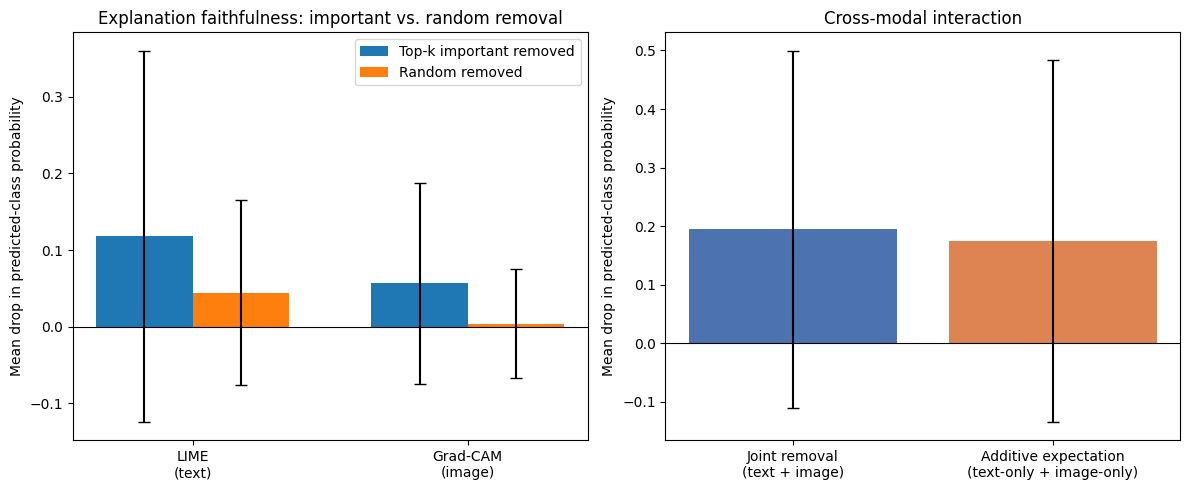

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["LIME\n(text)", "Grad-CAM\n(image)"]
top_means = [faithfulness_df["text_top_drop"].mean(), faithfulness_df["image_top_drop"].mean()]
top_stds = [faithfulness_df["text_top_drop"].std(), faithfulness_df["image_top_drop"].std()]
rand_means = [faithfulness_df["text_random_drop"].mean(), faithfulness_df["image_random_drop"].mean()]
rand_stds = [faithfulness_df["text_random_drop"].std(), faithfulness_df["image_random_drop"].std()]

x = np.arange(len(labels))
width = 0.35
axes[0].bar(x - width / 2, top_means, width, yerr=top_stds, capsize=4, label="Top-k important removed")
axes[0].bar(x + width / 2, rand_means, width, yerr=rand_stds, capsize=4, label="Random removed")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Mean drop in predicted-class probability")
axes[0].set_title("Explanation faithfulness: important vs. random removal")
axes[0].legend()
axes[0].axhline(0, color="black", linewidth=0.8)

joint_mean = faithfulness_df["joint_drop"].mean()
joint_std = faithfulness_df["joint_drop"].std()
additive_mean = faithfulness_df["additive_expectation"].mean()
additive_std = faithfulness_df["additive_expectation"].std()

axes[1].bar(
    ["Joint removal\n(text + image)", "Additive expectation\n(text-only + image-only)"],
    [joint_mean, additive_mean],
    yerr=[joint_std, additive_std], capsize=4, color=["#4C72B0", "#DD8452"]
)
axes[1].set_ylabel("Mean drop in predicted-class probability")
axes[1].set_title("Cross-modal interaction")
axes[1].axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("faithfulness_results.png", dpi=200)
plt.show()

**How to report this in the paper / rebuttal:**

Report `summary_table` (Mean prob. drop ± Std for each of the six rows
above) as a new table in the Explainability section, and include
`faithfulness_results.png` as a figure. The key claims this supports:

- If `text_top_drop` >> `text_random_drop` (and the paired Wilcoxon test is
  significant), LIME's token importances are faithful: removing the words
  LIME flagged hurts the prediction far more than removing an equal number
  of random words would.
- Symmetrically for `image_top_drop` vs `image_random_drop` and Grad-CAM.
- If `joint_drop` > `additive_expectation` (positive `interaction_effect`,
  significant Wilcoxon test), that is direct quantitative evidence of a
  cross-modal interaction -- the model's use of the flagged image region
  depends on the flagged text (or vice versa), not just independent
  per-modality contributions -- directly answering the reviewer's point
  that the original evaluation never measured this.